<a href="https://colab.research.google.com/github/MohamedHouij03/Deep_learning/blob/main/experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Experiment


## 1) Setup and imports

In [ ]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2) Dataset loading

We use the Roboflow export already available locally: `test_project.v1i.tensorflow`.
Each split has images + `_annotations.csv` with bbox coordinates and class names.

In [ ]:
!pip install roboflow

from roboflow import Roboflow

# Roboflow details from another cell's context (e766383e)
ROBOFLOW_API_KEY = "42mQFkO0TBeDGHlzZPVk"
ROBOFLOW_WORKSPACE = "mohamed-houij"
ROBOFLOW_PROJECT = "testing_football"
ROBOFLOW_VERSION = 1
ROBOFLOW_FORMAT = "tensorflow" # This is the format for the classification task

# Determine the expected download directory name
expected_dataset_folder_name = f"{ROBOFLOW_PROJECT}.v{ROBOFLOW_VERSION}i.{ROBOFLOW_FORMAT}"
ROBOFLOW_LOCAL_PATH = Path(expected_dataset_folder_name)

# Check if the dataset already exists locally
if not ROBOFLOW_LOCAL_PATH.exists():
    print(f"Dataset '{ROBOFLOW_LOCAL_PATH}' not found locally. Attempting to download from Roboflow...")
    try:
        rf = Roboflow(api_key=ROBOFLOW_API_KEY)
        project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
        # Download the 'tensorflow' format for the classification task
        ds = project.version(ROBOFLOW_VERSION).download(ROBOFLOW_FORMAT)
        DATASET_DIR = Path(ds.location)
        print(f"Dataset downloaded to: {DATASET_DIR}")
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        print("Please ensure the Roboflow API key, workspace, project, and version are correct, and you have network access.")
        # If download fails, fall back to the original `sample_data` to allow the error to manifest
        # so the user understands the data is missing.
        DATASET_DIR = Path('sample_data')
else:
    print(f"Dataset '{ROBOFLOW_LOCAL_PATH}' found locally. Using it.")
    DATASET_DIR = ROBOFLOW_LOCAL_PATH

SPLITS = ['train', 'valid', 'test']

assert DATASET_DIR.exists(), f'Missing dataset directory: {DATASET_DIR.resolve()}'

def load_annotations(root, split):
    df = pd.read_csv(root / split / '_annotations.csv')
    df = df.dropna(subset=['filename', 'class']).copy()
    for c in ['width', 'height', 'xmin', 'ymin', 'xmax', 'ymax']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['width', 'height', 'xmin', 'ymin', 'xmax', 'ymax']).copy()
    df['split'] = split
    return df

ann = {s: load_annotations(DATASET_DIR, s) for s in SPLITS}
all_ann = pd.concat(ann.values(), ignore_index=True)

for s, df in ann.items():
    print(f"{s}: {len(df)} annotations, {df['filename'].nunique()} unique images")

class_names = sorted(all_ann['class'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print('Classes:', class_names)
print('Num classes:', len(class_names))

Dataset 'testing_football.v1i.tensorflow' not found locally. Attempting to download from Roboflow...
loading Roboflow workspace...
loading Roboflow project...
Exporting format tensorflow in progress : 95.0%
Version export complete for tensorflow format



Extracting Dataset Version Zip to Testing_football-1 in tensorflow:: 100%|██████████| 6690/6690 [00:04<00:00, 1549.13it/s]


Dataset downloaded to: /content/Testing_football-1
train: 12986 annotations, 5934 unique images
valid: 1478 annotations, 602 unique images
test: 371 annotations, 149 unique images
Classes: ['Arbitre', 'Ballon', 'Football', 'Gardien', 'Joueur', 'Player', 'ball', 'big', 'person', 'player', 'refere']
Num classes: 11


## 3) Image preprocessing

For this experimentation stage, we convert object detection annotations into a classification dataset by cropping each bounding box and assigning its class label.

This allows fair comparison of many neural architectures quickly.

In [ ]:
IMG_SIZE = (64, 64)
MAX_SAMPLES_PER_SPLIT = {
    'train': 6000,
    'valid': 2000,
    'test': 2000
}

def safe_crop(img, xmin, ymin, xmax, ymax):
    h, w = img.shape[:2]
    xmin = int(max(0, min(xmin, w - 1)))
    xmax = int(max(1, min(xmax, w)))
    ymin = int(max(0, min(ymin, h - 1)))
    ymax = int(max(1, min(ymax, h)))

    if xmax <= xmin:
        xmax = min(w, xmin + 1)
    if ymax <= ymin:
        ymax = min(h, ymin + 1)

    return img[ymin:ymax, xmin:xmax]

def build_split_arrays(root, split, ann_df, img_size=(64, 64), max_samples=None):
    records = ann_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    if max_samples is not None:
        records = records.iloc[:max_samples]

    x_data = []
    y_data = []

    for _, row in records.iterrows():
        img_path = root / split / row['filename']
        if not img_path.exists():
            continue

        img_bytes = tf.io.read_file(str(img_path))
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = img.numpy()

        crop = safe_crop(img, row['xmin'], row['ymin'], row['xmax'], row['ymax'])
        crop = tf.image.resize(crop, img_size).numpy().astype('float32') / 255.0

        x_data.append(crop)
        y_data.append(class_to_idx[row['class']])

    x_data = np.array(x_data, dtype='float32')
    y_data = np.array(y_data, dtype='int32')
    return x_data, y_data

x_train, y_train = build_split_arrays(DATASET_DIR, 'train', ann['train'], IMG_SIZE, MAX_SAMPLES_PER_SPLIT['train'])
x_valid, y_valid = build_split_arrays(DATASET_DIR, 'valid', ann['valid'], IMG_SIZE, MAX_SAMPLES_PER_SPLIT['valid'])
x_test, y_test = build_split_arrays(DATASET_DIR, 'test', ann['test'], IMG_SIZE, MAX_SAMPLES_PER_SPLIT['test'])

print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_valid:', x_valid.shape, 'y_valid:', y_valid.shape)
print('x_test :', x_test.shape, 'y_test :', y_test.shape)

x_train: (6000, 64, 64, 3) y_train: (6000,)
x_valid: (1478, 64, 64, 3) y_valid: (1478,)
x_test : (371, 64, 64, 3) y_test : (371,)


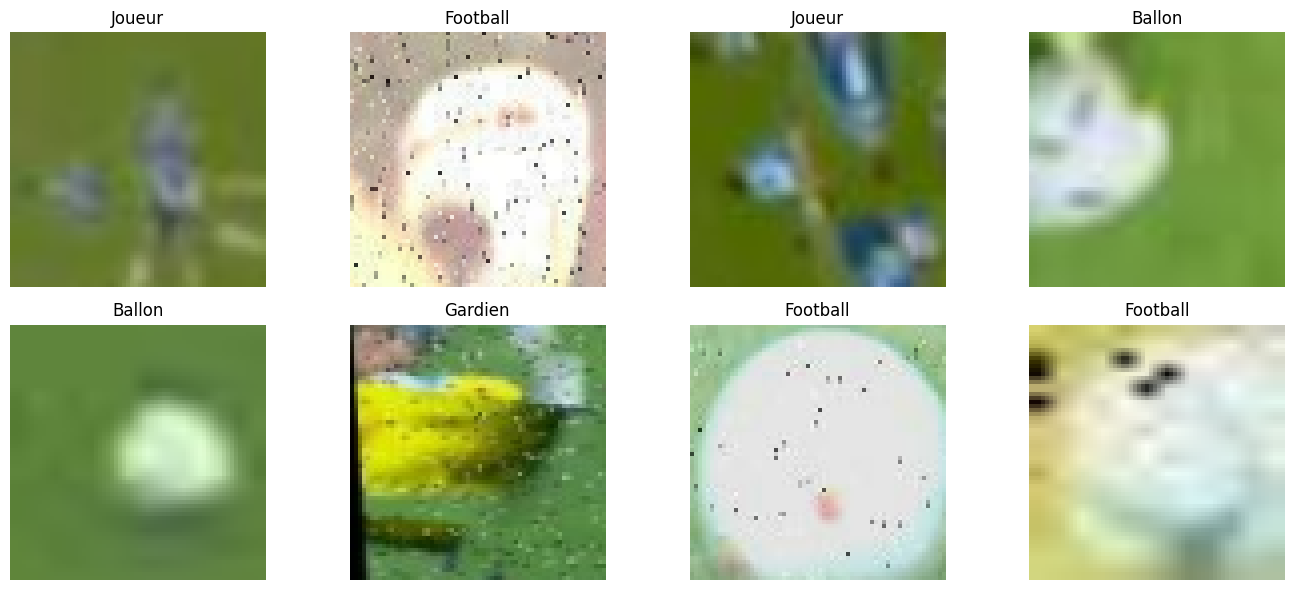

In [ ]:
def show_samples(x, y, n=8):
    n = min(n, len(x))
    idxs = np.random.choice(len(x), size=n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3.5 * cols, 3 * rows))
    for i, idx in enumerate(idxs):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(x[idx])
        plt.title(idx_to_class[int(y[idx])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(x_train, y_train, n=8)

## 4) Train/validation/test preparation

In [ ]:
NUM_CLASSES = len(class_names)
BATCH_SIZE = 64

y_train_oh = keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_valid_oh = keras.utils.to_categorical(y_valid, num_classes=NUM_CLASSES)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_oh)).shuffle(2048, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_ds = tf.data.Dataset.from_tensor_slices((x_valid, y_valid_oh)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_oh)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 5) Metrics, evaluation helpers, and training utility

In [ ]:
results = []
histories = {}

def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_and_evaluate(model_name, model, epochs=8, learning_rate=1e-3, verbose=0):
    model = compile_model(model, learning_rate=learning_rate)
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]

    start = time.time()
    history = model.fit(train_ds, validation_data=valid_ds, epochs=epochs, verbose=verbose, callbacks=callbacks)
    train_time = time.time() - start

    val_loss, val_acc = model.evaluate(valid_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    row = {
        'model_name': model_name,
        'params': model.count_params(),
        'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
        'val_loss': float(val_loss),
        'val_acc': float(val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'train_time_sec': float(train_time)
    }

    results.append(row)
    histories[model_name] = history.history
    print(f"{model_name} -> val_acc={val_acc:.4f}, test_acc={test_acc:.4f}")
    return row

def results_df():
    if len(results) == 0:
        return pd.DataFrame()
    return pd.DataFrame(results).sort_values('test_acc', ascending=False).reset_index(drop=True)

def plot_histories(model_names, metric='accuracy'):
    plt.figure(figsize=(10, 5))
    for name in model_names:
        if name in histories:
            plt.plot(histories[name][metric], label=f'{name} train')
            plt.plot(histories[name]['val_' + metric], linestyle='--', label=f'{name} val')
    plt.title(f'Training curves ({metric})')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6) Experiment 1 - MLP architectures



MLP_BASELINE -> val_acc=0.4899, test_acc=0.6307


,model_name,params,best_epoch,val_loss,val_acc,test_loss,test_acc,train_time_sec
0,MLP_BASELINE,3214603,2,1.474298,0.489851,1.027773,0.630728,16.925281


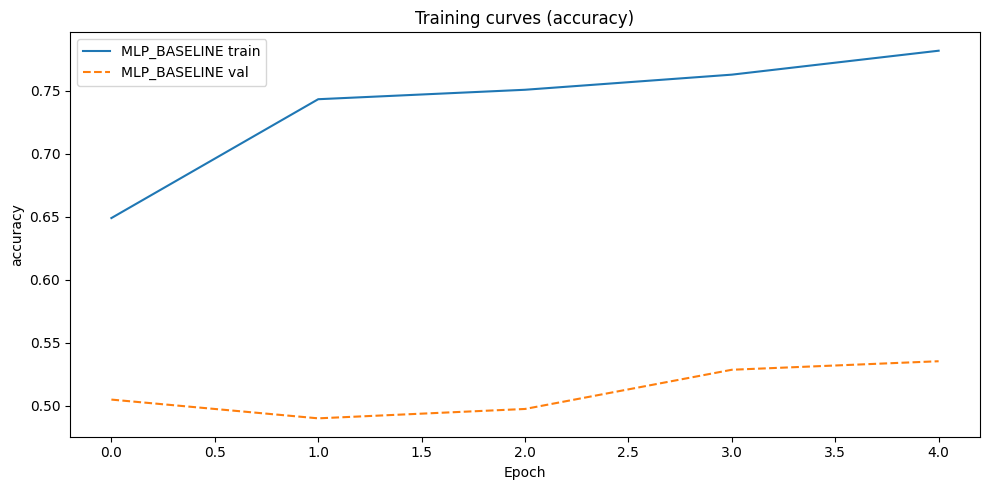

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

if 'IMG_SIZE' not in globals() or 'NUM_CLASSES' not in globals():
    raise RuntimeError('Run setup/data preparation cells first: IMG_SIZE and NUM_CLASSES are missing.')
if 'train_and_evaluate' not in globals() or 'results_df' not in globals() or 'plot_histories' not in globals():
    raise RuntimeError('Run helper cells first: train_and_evaluate/results_df/plot_histories are missing.')

def build_mlp(hidden_layers=(256,), activation='relu', dropout=0.0, l2_value=0.0):
    reg = regularizers.l2(l2_value) if l2_value > 0 else None
    model = keras.Sequential(name='mlp')
    model.add(layers.Input(shape=(*IMG_SIZE, 3)))
    model.add(layers.Flatten())

    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation, kernel_regularizer=reg))
        if dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

mlp_name = 'MLP_BASELINE'
mlp_model = build_mlp(hidden_layers=(256, 256), activation='relu')
train_and_evaluate(mlp_name, mlp_model, epochs=8, learning_rate=1e-3, verbose=0)

display(results_df())
plot_histories([mlp_name], metric='accuracy')

Short conclusion: deeper MLPs may help up to a point, but overfitting can appear quickly on flattened image inputs.

## 7) Removed (Activation sweep)

Removed to keep exactly four models in this phase.

In [ ]:
print('Activation sweep removed. Keeping only MLP, CNN, RNN, and LSTM baselines.')

Activation sweep removed. Keeping only MLP, CNN, RNN, and LSTM baselines.


Short conclusion: activation choice changes convergence behavior and generalization; ReLU/ELU are often stable baselines.

## 8) Removed (Learning-rate sweep)

Removed to keep exactly four models in this phase.

In [ ]:
print('Learning-rate sweep removed. Keeping only MLP, CNN, RNN, and LSTM baselines.')

Learning-rate sweep removed. Keeping only MLP, CNN, RNN, and LSTM baselines.


Short conclusion: too large learning rates can destabilize optimization, while too small rates may underfit in fixed epochs.

## 9) Removed (Regularization sweep)

Removed to keep exactly four models in this phase.

In [ ]:
print('Regularization sweep removed. Keeping only MLP, CNN, RNN, and LSTM baselines.')

Regularization sweep removed. Keeping only MLP, CNN, RNN, and LSTM baselines.


Short conclusion: regularization generally improves robustness by reducing overfitting, especially on dense models.

## 10) Experiment 5 - CNN architectures

CNNs exploit spatial locality and usually outperform MLPs on image tasks.

CNN_BASELINE -> val_acc=0.5135, test_acc=0.7062


,model_name,params,best_epoch,val_loss,val_acc,test_loss,test_acc,train_time_sec
0,CNN_BASELINE,1143371,1,1.517133,0.513532,0.961558,0.706199,13.495904
1,MLP_BASELINE,3214603,2,1.474298,0.489851,1.027773,0.630728,16.925281


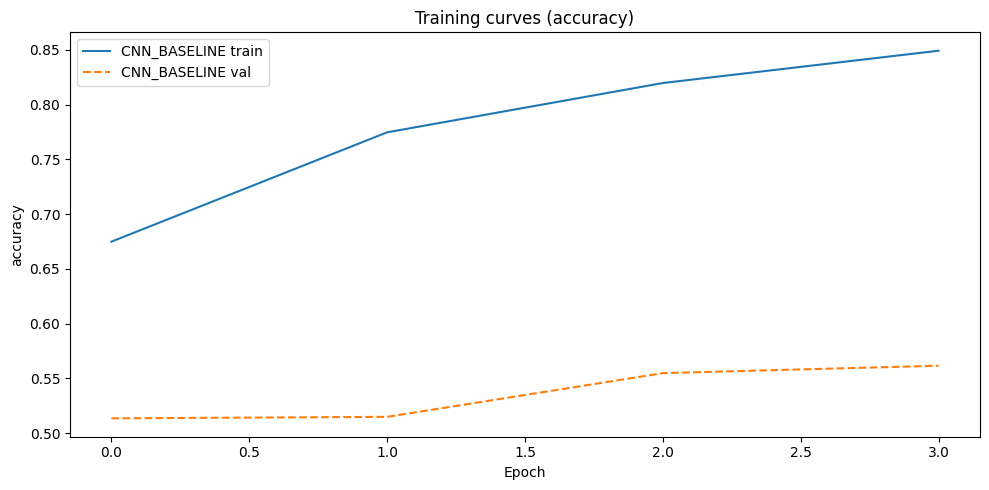

In [ ]:
def build_cnn(conv_blocks=((32, 3), (64, 3)), dense_units=128, dropout=0.0):
    model = keras.Sequential(name='cnn')
    model.add(layers.Input(shape=(*IMG_SIZE, 3)))

    for filters, kernel in conv_blocks:
        model.add(layers.Conv2D(filters, kernel_size=(kernel, kernel), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    if dropout > 0:
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

cnn_name = 'CNN_BASELINE'
cnn_model = build_cnn(conv_blocks=((32, 3), (64, 3), (128, 3)), dense_units=128, dropout=0.3)
train_and_evaluate(cnn_name, cnn_model, epochs=10, learning_rate=1e-3, verbose=0)

display(results_df())
plot_histories([cnn_name], metric='accuracy')

Short conclusion: CNN models are expected to be strong baselines due to image-specific inductive biases.

## 11) Experiment 6 - RNN on image sequences

We reshape each image from `(H, W, C)` to a sequence of `H` steps with `W*C` features per step.

This is usually less suitable than CNNs for images, but useful for comparison.

RNN_BASELINE -> val_acc=0.4229, test_acc=0.4825


,model_name,params,best_epoch,val_loss,val_acc,test_loss,test_acc,train_time_sec
0,CNN_BASELINE,1143371,1,1.517133,0.513532,0.961558,0.706199,13.495904
1,MLP_BASELINE,3214603,2,1.474298,0.489851,1.027773,0.630728,16.925281
2,RNN_BASELINE,42507,3,1.556739,0.422869,1.354238,0.482480,11.020767


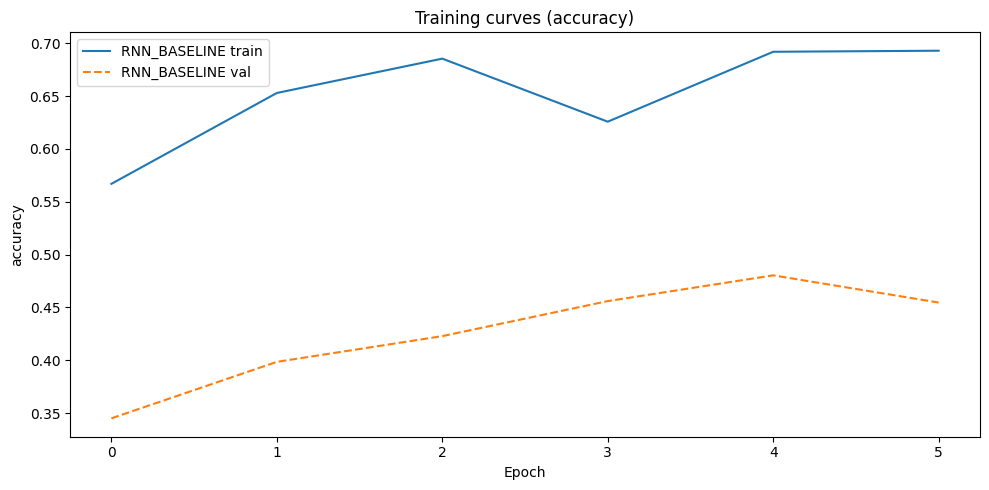

In [ ]:
def to_sequence(x):
    n, h, w, c = x.shape
    return x.reshape(n, h, w * c)

x_train_seq = to_sequence(x_train)
x_valid_seq = to_sequence(x_valid)
x_test_seq = to_sequence(x_test)

train_seq_ds = tf.data.Dataset.from_tensor_slices((x_train_seq, y_train_oh)).shuffle(2048, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_seq_ds = tf.data.Dataset.from_tensor_slices((x_valid_seq, y_valid_oh)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_seq_ds = tf.data.Dataset.from_tensor_slices((x_test_seq, y_test_oh)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def train_and_evaluate_sequence(model_name, model, epochs=8, learning_rate=1e-3, verbose=0):
    model = compile_model(model, learning_rate=learning_rate)
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

    start = time.time()
    history = model.fit(train_seq_ds, validation_data=valid_seq_ds, epochs=epochs, verbose=verbose, callbacks=callbacks)
    train_time = time.time() - start

    val_loss, val_acc = model.evaluate(valid_seq_ds, verbose=0)
    test_loss, test_acc = model.evaluate(test_seq_ds, verbose=0)

    row = {
        'model_name': model_name,
        'params': model.count_params(),
        'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
        'val_loss': float(val_loss),
        'val_acc': float(val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'train_time_sec': float(train_time)
    }
    results.append(row)
    histories[model_name] = history.history
    print(f"{model_name} -> val_acc={val_acc:.4f}, test_acc={test_acc:.4f}")
    return row

def build_simple_rnn(units=128):
    inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1] * 3))
    x = layers.SimpleRNN(units)(inp)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out)

rnn_name = 'RNN_BASELINE'
rnn_model = build_simple_rnn(units=128)
train_and_evaluate_sequence(rnn_name, rnn_model, epochs=8, learning_rate=1e-3, verbose=0)

display(results_df())
plot_histories([rnn_name], metric='accuracy')

Short conclusion: RNNs can learn some structure, but they are not naturally suited for 2D spatial invariances in images.

## 12) Experiment 7 - LSTM variants

We test LSTM and Bidirectional LSTM on the same sequence representation for comparison with RNN/CNN.

LSTM_BASELINE -> val_acc=0.5169, test_acc=0.7709


,model_name,params,best_epoch,val_loss,val_acc,test_loss,test_acc,train_time_sec
0,LSTM_BASELINE,165771,5,1.531481,0.516915,0.840885,0.770889,11.391042
1,CNN_BASELINE,1143371,1,1.517133,0.513532,0.961558,0.706199,13.495904
2,MLP_BASELINE,3214603,2,1.474298,0.489851,1.027773,0.630728,16.925281
3,RNN_BASELINE,42507,3,1.556739,0.422869,1.354238,0.482480,11.020767


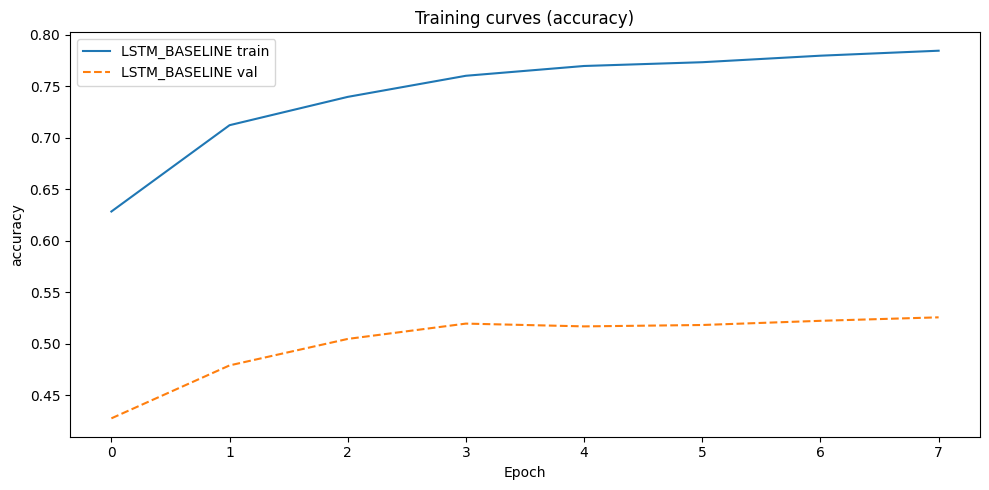

In [ ]:
def build_lstm(units=128):
    inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1] * 3))
    x = layers.LSTM(units)(inp)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out)

lstm_name = 'LSTM_BASELINE'
lstm_model = build_lstm(units=128)
train_and_evaluate_sequence(lstm_name, lstm_model, epochs=8, learning_rate=1e-3, verbose=0)

display(results_df())
plot_histories([lstm_name], metric='accuracy')

Short conclusion: LSTMs may improve over SimpleRNN on long dependencies, but CNNs are typically more efficient/effective for images.

## 13) Final comparison tables and visuals

,model_name,params,best_epoch,val_loss,val_acc,test_loss,test_acc,train_time_sec
0,LSTM_BASELINE,165771,5,1.531481,0.516915,0.840885,0.770889,11.391042
1,CNN_BASELINE,1143371,1,1.517133,0.513532,0.961558,0.706199,13.495904
2,MLP_BASELINE,3214603,2,1.474298,0.489851,1.027773,0.630728,16.925281
3,RNN_BASELINE,42507,3,1.556739,0.422869,1.354238,0.482480,11.020767


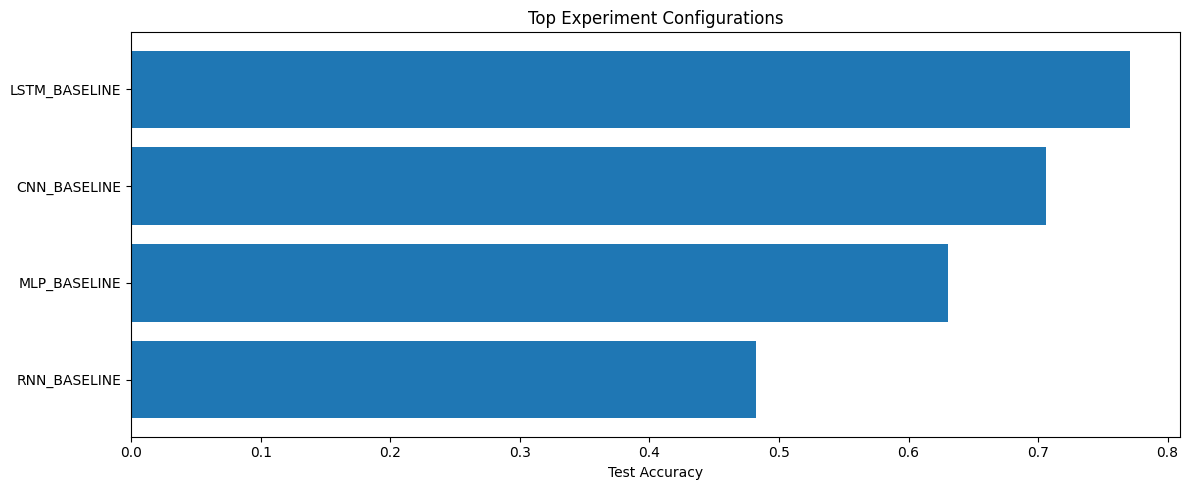

In [ ]:
df_results = results_df()
display(df_results)

plt.figure(figsize=(12, 5))
top_n = min(15, len(df_results))
plot_df = df_results.head(top_n).copy()
plt.barh(plot_df['model_name'][::-1], plot_df['test_acc'][::-1])
plt.xlabel('Test Accuracy')
plt.title('Top Experiment Configurations')
plt.tight_layout()
plt.show()

## YOLO model (object detection baseline)

This adds a YOLOv8 experiment for detection-oriented evaluation (mAP).

In [ ]:
# =====================================
# 1. INSTALL DEPENDENCIES
# =====================================
!pip install ultralytics roboflow -q

import os
import shutil
from pathlib import Path
from roboflow import Roboflow
from ultralytics import YOLO

# =====================================
# 2. CONFIGURATION
# =====================================
ROBOFLOW_API_KEY = "PUT_YOUR_KEY_HERE"
ROBOFLOW_WORKSPACE = "mohamed-houij"
ROBOFLOW_PROJECT = "testing_football"
ROBOFLOW_VERSION = 1

DATASET_NAME = f"{ROBOFLOW_PROJECT}.v{ROBOFLOW_VERSION}i.yolov8"
DATASET_DIR = Path("/content") / DATASET_NAME

# =====================================
# 3. DOWNLOAD DATASET
# =====================================
if not DATASET_DIR.exists():
    print("Downloading dataset from Roboflow...")

    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download("yolov8")

    if Path(dataset.location) != DATASET_DIR:
        shutil.move(dataset.location, DATASET_DIR)

print("Dataset ready at:", DATASET_DIR)

# =====================================
# 4. DATASET CHECK
# =====================================
print("\n=== DATASET STRUCTURE ===")
print(os.listdir(DATASET_DIR))

print("\nTrain:", os.listdir(DATASET_DIR / "train"))
print("Valid:", os.listdir(DATASET_DIR / "valid"))
print("Test:", os.listdir(DATASET_DIR / "test"))

label_files = list((DATASET_DIR / "train" / "labels").glob("*.txt"))
print("\nNumber of label files:", len(label_files))

with open(label_files[0], "r") as f:
    print("\nExample label file:")
    print(f.read())

# =====================================
# 5. CLASSES (KEEP ORIGINAL DATASET)
# =====================================
class_names = [
    'Arbitre', 'Ballon', 'Football', 'Gardien', 'Joueur',
    'Player', 'ball', 'big', 'person', 'player', 'refere'
]

print("\n✔ Classes used:")
print(class_names)

# =====================================
# 6. CREATE data.yaml
# =====================================
data_yaml = DATASET_DIR / "data.yaml"

data_yaml_content = f"""
train: {DATASET_DIR}/train/images
val: {DATASET_DIR}/valid/images
test: {DATASET_DIR}/test/images

nc: {len(class_names)}
names: {class_names}
"""

with open(data_yaml, "w") as f:
    f.write(data_yaml_content)

print("\n✔ data.yaml created:\n")
print(data_yaml_content)

# =====================================
# 7. LOAD MODEL
# =====================================
model = YOLO("yolov8n.pt")

# =====================================
# 8. TRAINING
# =====================================
print("\n🚀 Starting training...")

model.train(
    data=str(data_yaml),
    epochs=50,
    imgsz=640,
    batch=16,
    project="runs_yolo",
    name="football_yolov8_full",
    verbose=True
)

# =====================================
# 9. VALIDATION
# =====================================
val_metrics = model.val(data=str(data_yaml), split="val")
test_metrics = model.val(data=str(data_yaml), split="test")

print("\nValidation mAP50:", val_metrics.box.map50)
print("Test mAP50:", test_metrics.box.map50)

# =====================================
# 10. TEST PREDICTION
# =====================================
model.predict(
    source=str(DATASET_DIR / "test/images"),
    save=True
)

print("\n✔ Predictions saved in runs folder")

Dataset ready at: /content/testing_football.v1i.yolov8

=== DATASET STRUCTURE ===
['train', 'data.yaml', 'valid', 'test', 'README.roboflow.txt', 'README.dataset.txt']

Train: ['labels', 'images']
Valid: ['labels', 'images']
Test: ['labels', 'images']

Number of label files: 5934

Example label file:
2 0.7296875 0.52890625 0.00625 0.0125

✔ Classes used:
['Arbitre', 'Ballon', 'Football', 'Gardien', 'Joueur', 'Player', 'ball', 'big', 'person', 'player', 'refere']

✔ data.yaml created:


train: /content/testing_football.v1i.yolov8/train/images
val: /content/testing_football.v1i.yolov8/valid/images
test: /content/testing_football.v1i.yolov8/test/images

nc: 11
names: ['Arbitre', 'Ballon', 'Football', 'Gardien', 'Joueur', 'Player', 'ball', 'big', 'person', 'player', 'refere']


🚀 Starting training...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bg

In [1]:
!pip install gradio ultralytics -q
from ultralytics import YOLO
import gradio as gr

# Load your trained model
model = YOLO("/content/runs/detect/runs_yolo/football_yolov8_full/weights/best.pt")

def detect(image):
    results = model(image)
    annotated_image = results[0].plot()
    return annotated_image

app = gr.Interface(
    fn=detect,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Image(type="numpy"),
    title="⚽ Football Detection App",
    description="Upload a football image and detect players, ball, referee, etc."
)

app.launch(share=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/runs_yolo/football_yolov8_full/weights/best.pt'